# Laboratorium: Kompresja JPEG

### Zadanie 1 (3 punkty)

Twoim celem jest sprawdzenie, jak działa kompresja sygnału poprzez rzutowanie go na losową bazę ortogonalną i zachowanie tylko najważniejszych współczynników.

**Kroki do wykonania:**

1. **Generacja sygnału:** Wygeneruj wektor $x$ o długości $N = 1000$ z rozkładu normalnego $\mathcal{N}(0,1)$.
2. **Generacja bazy ortonormalnej:** Stwórz macierz ortogonalną $Q$ o wymiarach $1000 \times 1000$. Możesz to zrobić generując macierz losowych liczb i używając na niej rozkładu QR. Kolumny macierzy $Q$ będą Twoją nową bazą ortonormalną $e_1, e_2, \dots, e_N$.
3. **Obliczenie współrzędnych:** Oblicz współczynniki $\alpha_i$ sygnału $x$ w nowej bazie. Pamiętaj, że dla bazy ortonormalnej każdy współczynnik to iloczyn skalarny: $\alpha_i = \langle x, e_i \rangle$.
4. **Intuicja kompresyjna:** Znajdź i posortuj współczynniki $\alpha_i$ malejąco według ich wartości bezwzględnej $|\alpha_i|$. Chcemy wiedzieć, które z nich niosą najwięcej "energii" sygnału.
5. **Wykres energii:** Stwórz wykres skumulowanej energii sygnału bazując na wzorze Parsevala (gdzie energia to $\sum |\alpha_i|^2$). Niech oś X reprezentuje liczbę $k$ największych zachowanych współczynników, a oś Y – procent zachowanej całkowitej energii sygnału.
6. **Rekonstrukcja:** Napisz funkcję, która dla zadanego $k$:
   * Zostawia $k$ największych (co do modułu) współczynników.
   * Zeruje pozostałe $N - k$ współczynników.
   * Odtwarza przybliżony sygnał (dokonuje rzutu na podprzestrzeń).
7. **Analiza błędu:** Sporządź wykres sumy kwadratów błędów pomiędzy sygnałem oryginalnym a zrekonstruowanym w zależności od $k$. Zweryfikuj numerycznie teorię: czy błąd rekonstrukcji faktycznie równa się sumie energii odrzuconych współczynników?

In [ ]:
# your code

### Zadanie 2 (3 punkty)

Rozważ sygnał dźwiękowy zadany wzorem

$$
s(t) = \sin(2\pi \cdot 220\, t)
+ 0.7 \sin(2\pi \cdot 440\, t)
+ 0.3 \sin(2\pi \cdot 880\, t),
$$

gdzie:
- $ t \in [0,5] $ oznacza czas wyrażony w sekundach,
- częstotliwości $220$, $440$ i $880$ Hz odpowiadają różnym składowym tonalnym sygnału.

Sygnał należy próbkować z częstotliwością $f_s = 8000 \text{ Hz}$.

### Polecenie

1. Wygeneruj sygnał $ s(t) $ w postaci dyskretnej.
2. Podziel sygnał na krótkie okna czasowe.
3. Dla każdego okna oblicz dyskretną transformatę Fouriera (FFT).
4. Wygeneruj spektrogram sygnału.
5. Opisz otrzymany wynik.

W szczególności:
- wskaż dominujące częstotliwości,
- wyjaśnij, jak są one widoczne na spektrogramie,
- opisz zależność pomiędzy położeniem na osi pionowej a częstotliwością sygnału.

### Wskazówka

Można użyć funkcji:
- `scipy.signal.spectrogram`,
- `matplotlib.pyplot.specgram`,

In [ ]:
# your code

### Zadanie 3 (4 punkty)

W kompresji JPEG kluczowe jest dzielenie obrazu na małe obszary i aplikowanie do nich dwuwymiarowej transformaty cosinusowej. W tym zadaniu zaimplementujesz ten mechanizm całkowicie od podstaw.

**Polecenia do wykonania:**
1. Wczytaj czarno-biały obraz, uruchamiając komórkę poniżej.
2. Zaimplementuj funkcję obliczającą macierz współczynników $F(u, v)$ według wzoru z wykładu. Obowiązuje całkowity zakaz używania gotowych implementacji DCT (np. z biblioteki `scipy.fftpack`).
3. Wyświetl obliczoną macierz współczynników. Zweryfikuj założenie teoretyczne: czy najwięcej energii faktycznie skupiło się w lewym górnym rogu macierzy?
4. Wykonaj symulację kompresji stratnej: zachowaj tylko współczynniki znajdujące się w obszarze 3x3 w lewym górnym rogu macierzy, a całą resztę (wysokie częstotliwości) wyzeruj.
5. Wyprowadź i zaimplementuj wzór na odwrotną transformatę cosinusową (IDCT). Odtwórz blok obrazu ze zmodyfikowanych współczynników i wyświetl go obok bloku oryginalnego, aby ocenić wizualne skutki kompresji.

**Kod startowy:**
Uruchom poniższą komórkę, aby wczytać sztuczny blok 8x8 reprezentujący wyraźną, ukośną krawędź, a następnie przejdź do realizacji poleceń.

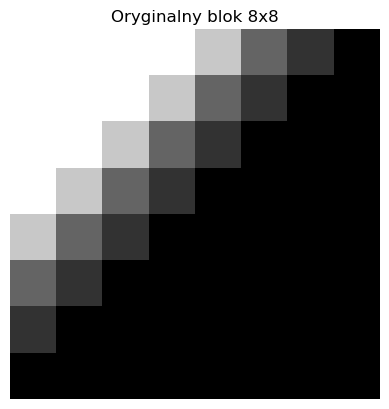

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Sztuczny blok 8x8 imitujący krawędź na zdjęciu
block = np.array([
    [255, 255, 255, 255, 200, 100,  50,   0],
    [255, 255, 255, 200, 100,  50,   0,   0],
    [255, 255, 200, 100,  50,   0,   0,   0],
    [255, 200, 100,  50,   0,   0,   0,   0],
    [200, 100,  50,   0,   0,   0,   0,   0],
    [100,  50,   0,   0,   0,   0,   0,   0],
    [ 50,   0,   0,   0,   0,   0,   0,   0],
    [  0,   0,   0,   0,   0,   0,   0,   0]
], dtype=float)

plt.imshow(block, cmap='gray', vmin=0, vmax=255)
plt.title("Oryginalny blok 8x8")
plt.axis('off')
plt.show()

In [ ]:
# your code

### Zadanie 4 (2 punkty)
Parametr jakości w JPEG wpływa na siłę kwantyzacji, co decyduje o kompromisie między rozmiarem pliku a wiernością obrazu. Dodatkowo na wykładzie wyraźnie zaznaczono, że format ten świetnie nadaje się do fotografii, ale zawodzi przy tekście i rysunkach technicznych.

**Polecenia do wykonania:**

1. **Dane testowe:** Przygotuj dwa obrazy źródłowe, uruchamiając kod z komórki poniżej.
3. **Analiza kompresji:** Zmierz rozmiar każdego wygenerowanego pliku na dysku. Wygeneruj wykres zależności rozmiaru pliku od ustawionego poziomu jakości dla obu typów obrazów.
4. **Poszukiwanie artefaktów:** Wczytaj pliki zapisane z najniższą jakością (np. `quality = 10`). Wytnij z nich małe, powiększone fragmenty (np. 50x50 pikseli) i wyświetl je na ekranie. Zlokalizuj i zademonstruj zjawiska opisane na wykładzie:
   * **Blokowość:** Wskaż miejsca, gdzie wyraźnie widać siatkę bloków 8x8.
   * **Ringing:** Zaobserwuj "fałszywe oscylacje" i szum wokół ostrych krawędzi liter.
5. **Mapa strat:** Dla wybranego obrazu oblicz bezwzględną różnicę wartości pikseli pomiędzy oryginałem a skompresowaną wersją. Wyświetl wynikową "mapę błędu". Odpowiedz na podstawie wizualizacji: gdzie kompresja JPEG "myli się" najbardziej – na gładkich powierzchniach, czy na ostrych krawędziach?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from PIL import Image
import os

# 1. Fotografia
photo_array = data.chelsea()
photo_img = Image.fromarray(photo_array)
photo_img.save("photo.png")

# 2. Tekst
text_array = data.page()
text_img = Image.fromarray(text_array)
text_img.save("text.png")

print("Obrazy 'photo.png' oraz 'text.png' zostały wygenerowane i zapisane.")

Obrazy 'photo.png' oraz 'text.png' zostały wygenerowane i zapisane.


In [ ]:
# your code